In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
datasets_normal_10 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
datasets_student   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")



In [3]:
def collect_dim(datasets, key, dim):
    return np.concatenate([
        np.asarray(d[key])[:, dim]
        for d in datasets
    ])


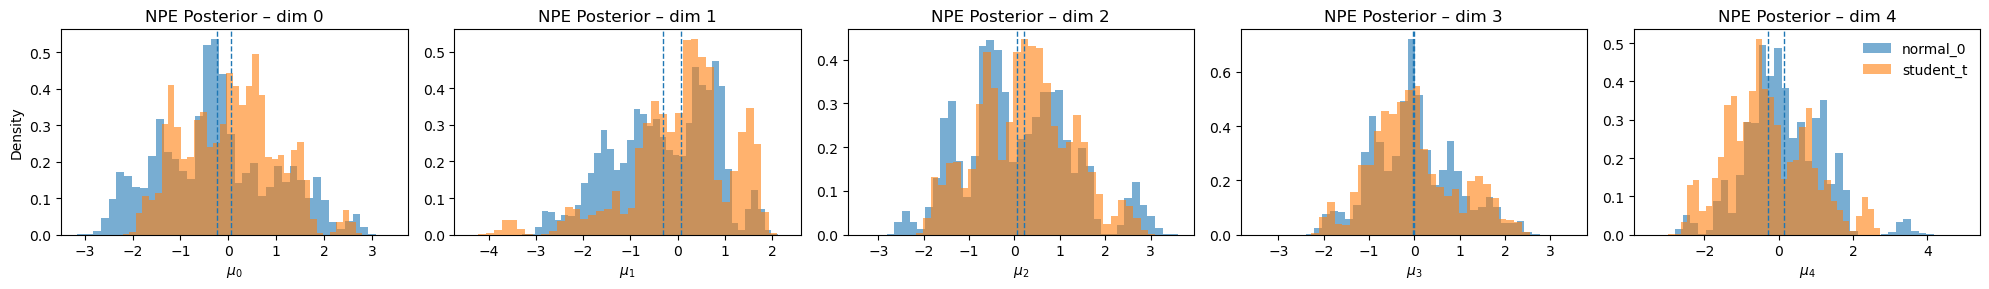

In [ ]:
# compare NPE posterior samples distribution
import matplotlib.pyplot as plt

D = 5
fig, axes = plt.subplots(1, D, figsize=(4*D, 3), sharey=False)

for dim in range(D):
    ax = axes[dim]

    normal_vals  = collect_dim(datasets_normal_0, key="npe_post_samples",dim=dim)
    student_vals = collect_dim(datasets_student, key="npe_post_samples",dim=dim)
    
    ax.hist(
        normal_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="normal_0"
    )
    ax.hist(
        student_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="student_t"
    )

    # posterior mean
    ax.axvline(normal_vals.mean(),  linestyle="--", linewidth=1)
    ax.axvline(student_vals.mean(), linestyle="--", linewidth=1)

    ax.set_title(f"NPE Posterior – dim {dim}")
    ax.set_xlabel(rf"$\mu_{dim}$")

    if dim == 0:
        ax.set_ylabel("Density")

axes[-1].legend(frameon=False)

plt.tight_layout()
plt.show()


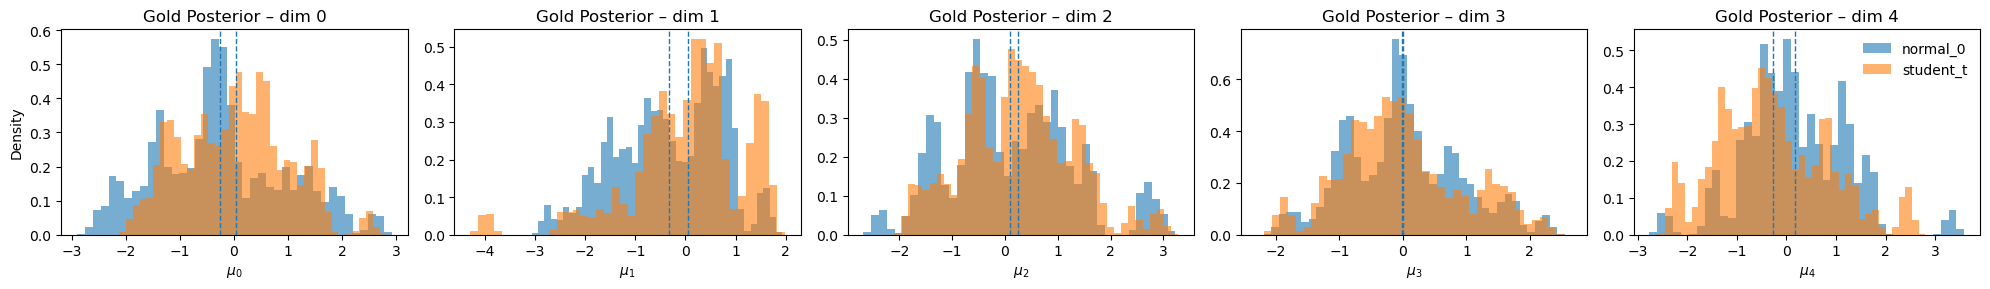

In [4]:
# compare analytical posterior samples distribution
import matplotlib.pyplot as plt

D = 5
fig, axes = plt.subplots(1, D, figsize=(4*D, 3), sharey=False)

for dim in range(D):
    ax = axes[dim]

    normal_vals  = collect_dim(datasets_normal_0, key="gold_post_samples",dim=dim)
    student_vals = collect_dim(datasets_student, key="gold_post_samples",dim=dim)
    
    ax.hist(
        normal_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="normal_0"
    )
    ax.hist(
        student_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="student_t"
    )

    # posterior mean
    ax.axvline(normal_vals.mean(),  linestyle="--", linewidth=1)
    ax.axvline(student_vals.mean(), linestyle="--", linewidth=1)

    ax.set_title(f"Gold Posterior – dim {dim}")
    ax.set_xlabel(rf"$\mu_{dim}$")

    if dim == 0:
        ax.set_ylabel("Density")

axes[-1].legend(frameon=False)

plt.tight_layout()
plt.show()


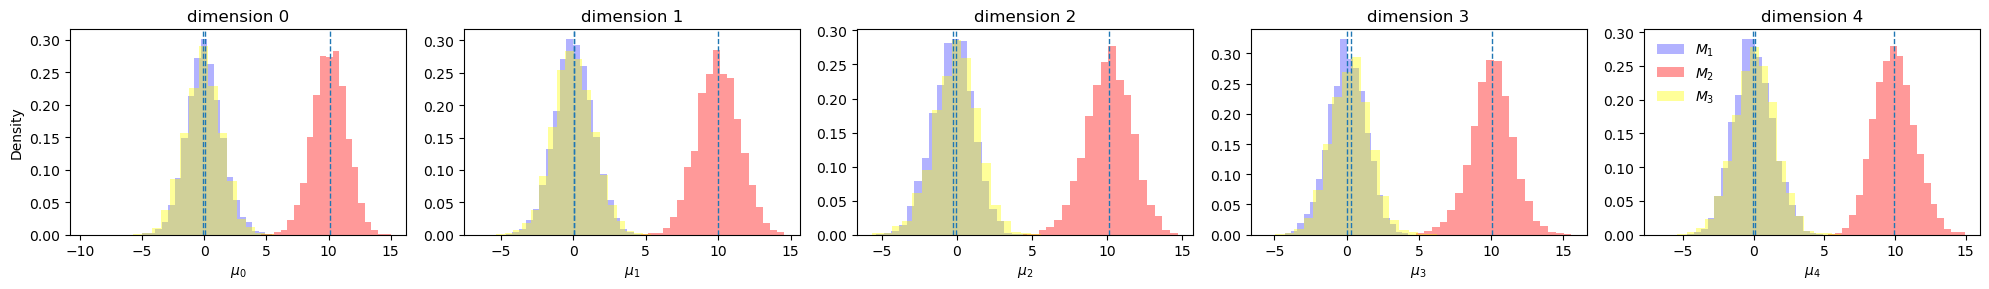

In [9]:
# compare the observation distributions
import matplotlib.pyplot as plt

D = 5
fig, axes = plt.subplots(1, D, figsize=(4*D, 3), sharey=False)

for dim in range(D):
    ax = axes[dim]

    normal_vals_0  = collect_dim(datasets_normal_0, key="obs_data",dim=dim)
    normal_vals_10  = collect_dim(datasets_normal_10, key="obs_data",dim=dim)
    student_vals = collect_dim(datasets_student, key="obs_data",dim=dim)
    
    ax.hist(
        normal_vals_0,
        bins=20,
        density=True,
        alpha=0.3,
        color="blue",
        label=r"$M_1$"
    )
    
    ax.hist(
        normal_vals_10,
        bins=20,
        density=True,
        alpha=0.4,
        color="red",
        label=r"$M_2$"
    )
    ax.hist(
        student_vals,
        bins=20,
        density=True,
        alpha=0.4,
        color="yellow",
        label=r"$M_3$"
    )

    # posterior mean
    ax.axvline(normal_vals_0.mean(),  linestyle="--", linewidth=1)
    ax.axvline(normal_vals_10.mean(),  linestyle="--", linewidth=1)
    ax.axvline(student_vals.mean(), linestyle="--", linewidth=1)

    ax.set_title(f"dimension {dim}")
    ax.set_xlabel(rf"$\mu_{dim}$")

    if dim == 0:
        ax.set_ylabel("Density")

axes[-1].legend(frameon=False)

plt.tight_layout()
plt.show()


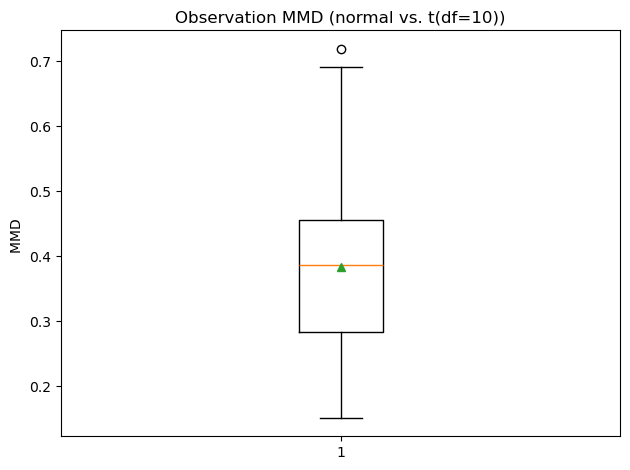

Normal Group Mean Kurtosis (First 5): [ 0.11408175 -0.29208079  0.33411605 -0.05202857  0.66178143]
Student Group Mean Kurtosis (First 5): [3.68480668 0.39947628 1.57872572 0.34244622 0.75505679]


In [6]:
from bayesflow.metrics import MaximumMeanDiscrepancy
import tensorflow as tf
from scipy.stats import kurtosis

obs_normal=[np.asarray(d['obs_data']) for d in datasets_normal_0]
obs_student=[np.asarray(d['obs_data']) for d in datasets_student]
mmd=MaximumMeanDiscrepancy(kernel='gaussian')
MMD_list=[]
for i in range(len(obs_normal)):
    X=tf.convert_to_tensor(obs_normal[i],dtype=np.float32)
    Y=tf.convert_to_tensor(obs_student[i],dtype=np.float32)
    MMD=float(mmd(X,Y))
    MMD_list.append(MMD)
    
plt.figure()
plt.boxplot(MMD_list, showmeans=True)
plt.ylabel("MMD ")
plt.title("Observation MMD (normal vs. t(df=10))")
plt.tight_layout()
plt.show()

kurt_normal = kurtosis(obs_normal, axis=1, fisher=True)   # Shape: (50, 5)
kurt_student = kurtosis(obs_student, axis=1, fisher=True) # Shape: (50, 5)
mean_kurt_normal = np.mean(kurt_normal, axis=1) # Shape: (50,)
mean_kurt_student = np.mean(kurt_student, axis=1) # Shape: (50,)
print("Normal Group Mean Kurtosis (First 5):", mean_kurt_normal[:5])
print("Student Group Mean Kurtosis (First 5):", mean_kurt_student[:5])

In [7]:
def summarize_obs(obs):
    """
    obs: array of shape (n_obs, D)
    return: feature vector of shape (2*D,)
    """
    mean = obs.mean(axis=0)
    std  = obs.std(axis=0)
    return np.concatenate([mean, std])
# normal_0
X_normal = np.array([
    summarize_obs(np.asarray(d["obs_data"]))
    for d in datasets_normal_0
])

# student_t
X_student = np.array([
    summarize_obs(np.asarray(d["obs_data"]))
    for d in datasets_student
])

X = np.vstack([X_normal, X_student])
y = np.array([0]*len(X_normal) + [1]*len(X_student))

In [8]:
def summarize_mean_only(obs):
    obs = np.asarray(obs, dtype=float)
    return obs.mean(axis=0)

X_normal = np.array([summarize_mean_only(d["obs_data"]) for d in datasets_normal_0])
X_student = np.array([summarize_mean_only(d["obs_data"]) for d in datasets_student])
X = np.vstack([X_normal, X_student])
y = np.array([0]*len(X_normal) + [1]*len(X_student))

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

clf = LogisticRegression(max_iter=500)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
aucs = []

for train, test in cv.split(X, y):
    clf.fit(X[train], y[train])
    probs = clf.predict_proba(X[test])[:, 1]
    aucs.append(roc_auc_score(y[test], probs))

print("AUC (mean ± sd):", np.mean(aucs), np.std(aucs))


AUC (mean ± sd): 0.57 0.17922053453775882


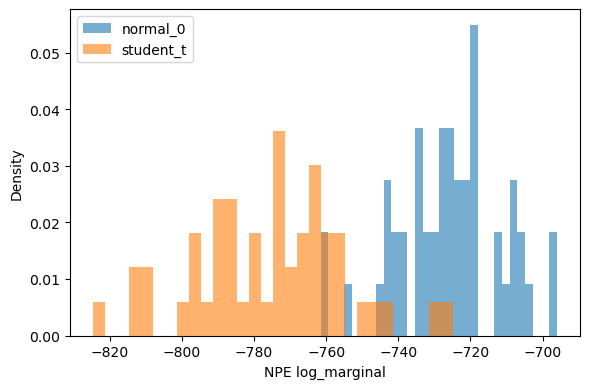

In [10]:
import numpy as np
import matplotlib.pyplot as plt

normal_vals = np.array([d["npe_log_marginal"] for d in datasets_normal_0], dtype=float)
student_vals = np.array([d["npe_log_marginal"] for d in datasets_student], dtype=float)

plt.figure(figsize=(6,4))
plt.hist(normal_vals, bins=30, alpha=0.6, density=True, label="normal_0")
plt.hist(student_vals, bins=30, alpha=0.6, density=True, label="student_t")
plt.xlabel("NPE log_marginal")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


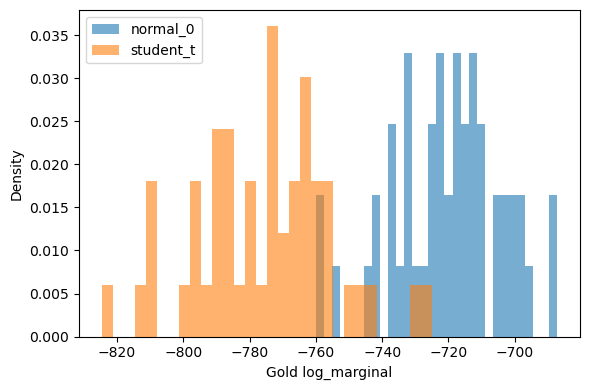

In [11]:

normal_vals = np.array([d["gold_log_marginal"] for d in datasets_normal_0], dtype=float)
student_vals = np.array([d["gold_log_marginal"] for d in datasets_student], dtype=float)

plt.figure(figsize=(6,4))
plt.hist(normal_vals, bins=30, alpha=0.6, density=True, label="normal_0")
plt.hist(student_vals, bins=30, alpha=0.6, density=True, label="student_t")
plt.xlabel("Gold log_marginal")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(datasets_normal_0[3]['gold_log_marginal'])
print(datasets_normal_02[3]['gold_log_marginal'])